In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Employee_Attrition_DataSet.csv")
#Explore dataset
df.head()


,EmployeeID,age,department,seniority,tenure,monthly_income,satisfaction_score,work_life_balance,overtime,commute_distance,promotion_last_5yrs,performance_score,trg_hrs_last_year,attrition
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   EmployeeID           10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   department           10000 non-null  object 
 3   seniority            10000 non-null  int64  
 4   tenure               10000 non-null  int64  
 5   monthly_income       10000 non-null  int64  
 6   satisfaction_score   10000 non-null  int64  
 7   work_life_balance    10000 non-null  int64  
 8   overtime             10000 non-null  object 
 9   commute_distance     10000 non-null  float64
 10  promotion_last_5yrs  10000 non-null  object 
 11  performance_score    10000 non-null  int64  
 12  trg_hrs_last_year    10000 non-null  int64  
 13  attrition            10000 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 898.5+ KB


In [3]:
df.describe()

,age,seniority,tenure,monthly_income,satisfaction_score,work_life_balance,commute_distance,performance_score,trg_hrs_last_year
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,37.693500,2.380800,7.788400,8967.918800,3.362100,2.761500,9.91074,2.603800,14.993100
std,9.376457,1.141368,7.141941,3500.745748,1.059951,0.893027,6.97463,0.737889,3.886227
min,22.000000,1.000000,0.000000,3000.000000,1.000000,1.000000,1.00000,1.000000,2.000000
25%,31.000000,1.000000,2.000000,6043.500000,3.000000,2.000000,4.70000,2.000000,12.000000
50%,37.000000,2.000000,6.000000,8670.000000,3.000000,3.000000,8.30000,3.000000,15.000000
75%,44.000000,3.000000,12.000000,11484.000000,4.000000,3.000000,13.40000,3.000000,18.000000
max,60.000000,5.000000,35.000000,21410.000000,5.000000,4.000000,50.00000,4.000000,31.000000


In [4]:
#All values look fine. No extreme outliers. No missing data
df['department'].value_counts()

department
Sales          2453
Engineering    2045
Operations     1513
Marketing      1188
Finance        1037
IT             1035
HR              729
Name: count, dtype: int64

In [5]:
df_subset = df.copy()
df_subset['overtime'] = df_subset['overtime'].replace({'No':0, 'Yes':1})
df_subset['promotion_last_5yrs'] = df_subset['promotion_last_5yrs'].replace({'No':0, 'Yes':1})
df_subset['attrition'] = df_subset['attrition'].replace({'No':0, 'Yes':1})
df_subset.head()

<ipython-input-5-0c392704bdfa>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_subset['overtime'] = df_subset['overtime'].replace({'No':0, 'Yes':1})
<ipython-input-5-0c392704bdfa>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_subset['promotion_last_5yrs'] = df_subset['promotion_last_5yrs'].replace({'No':0, 'Yes':1})
<ipython-input-5-0c392704bdfa>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy

,EmployeeID,age,department,seniority,tenure,monthly_income,satisfaction_score,work_life_balance,overtime,commute_distance,promotion_last_5yrs,performance_score,trg_hrs_last_year,attrition
0,EMP0000,42,Sales,3,9,9866,4,1,0,24.5,1,4,19,0
1,EMP0001,36,Sales,3,7,8958,3,3,0,10.0,0,2,13,0
2,EMP0002,44,Sales,4,16,11716,4,3,0,4.0,0,4,13,0
3,EMP0003,53,Finance,4,30,17061,5,3,0,7.1,0,3,20,0
4,EMP0004,35,HR,2,4,5738,2,3,0,8.4,0,2,15,0


In [8]:
#Replace categorical data with numerical data
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X = df_subset[['department']]
encoded_data = encoder.fit_transform(X)
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(X.columns))
encoded_df.head()

,department_Engineering,department_Finance,department_HR,department_IT,department_Marketing,department_Operations,department_Sales
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [9]:
#concat both database and do final data cleaning
df_subset = pd.concat([df_subset.drop('department', axis=1), encoded_df], axis=1)
df_subset.head()

,EmployeeID,age,seniority,tenure,monthly_income,satisfaction_score,work_life_balance,overtime,commute_distance,promotion_last_5yrs,performance_score,trg_hrs_last_year,attrition,department_Engineering,department_Finance,department_HR,department_IT,department_Marketing,department_Operations,department_Sales
0,EMP0000,42,3,9,9866,4,1,0,24.5,1,4,19,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,EMP0001,36,3,7,8958,3,3,0,10.0,0,2,13,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,EMP0002,44,4,16,11716,4,3,0,4.0,0,4,13,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,EMP0003,53,4,30,17061,5,3,0,7.1,0,3,20,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,EMP0004,35,2,4,5738,2,3,0,8.4,0,2,15,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [10]:
df_subset = df_subset.drop('EmployeeID', axis=1)
df_subset.head()

,age,seniority,tenure,monthly_income,satisfaction_score,work_life_balance,overtime,commute_distance,promotion_last_5yrs,performance_score,trg_hrs_last_year,attrition,department_Engineering,department_Finance,department_HR,department_IT,department_Marketing,department_Operations,department_Sales
0,42,3,9,9866,4,1,0,24.5,1,4,19,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,36,3,7,8958,3,3,0,10.0,0,2,13,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,44,4,16,11716,4,3,0,4.0,0,4,13,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,53,4,30,17061,5,3,0,7.1,0,3,20,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,35,2,4,5738,2,3,0,8.4,0,2,15,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [11]:
df_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     10000 non-null  int64  
 1   seniority               10000 non-null  int64  
 2   tenure                  10000 non-null  int64  
 3   monthly_income          10000 non-null  int64  
 4   satisfaction_score      10000 non-null  int64  
 5   work_life_balance       10000 non-null  int64  
 6   overtime                10000 non-null  int64  
 7   commute_distance        10000 non-null  float64
 8   promotion_last_5yrs     10000 non-null  int64  
 9   performance_score       10000 non-null  int64  
 10  trg_hrs_last_year       10000 non-null  int64  
 11  attrition               10000 non-null  int64  
 12  department_Engineering  10000 non-null  float64
 13  department_Finance      10000 non-null  float64
 14  department_HR           10000 non-null 

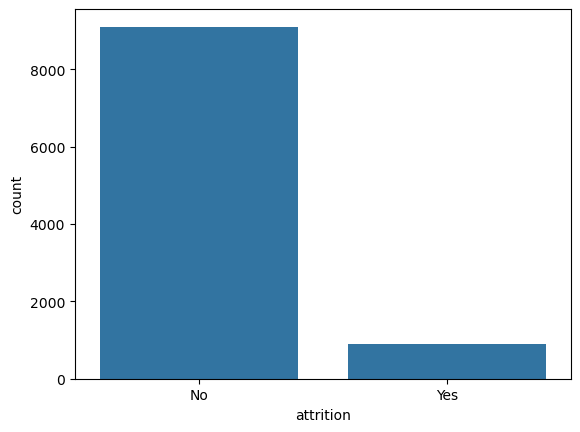

In [13]:
#EDA
import piplite
await piplite.install('seaborn')
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='attrition', data=df)
plt.show()

In [14]:
df_subset['attrition'].value_counts()

attrition
0    9097
1     903
Name: count, dtype: int64

<Axes: xlabel='department', ylabel='Count'>

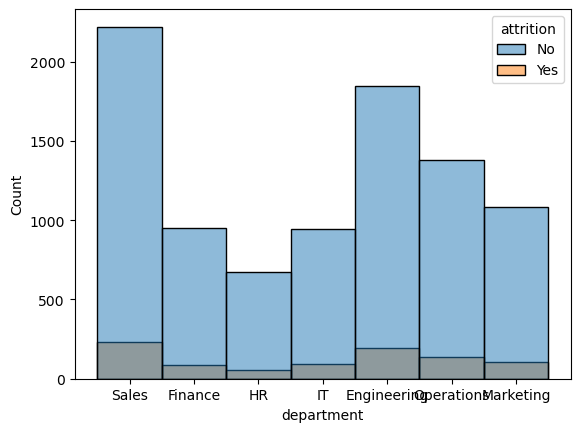

In [18]:
#91-9 split. May cause overfitting.
sns.histplot(x='department', hue='attrition', data=df)

<Axes: >

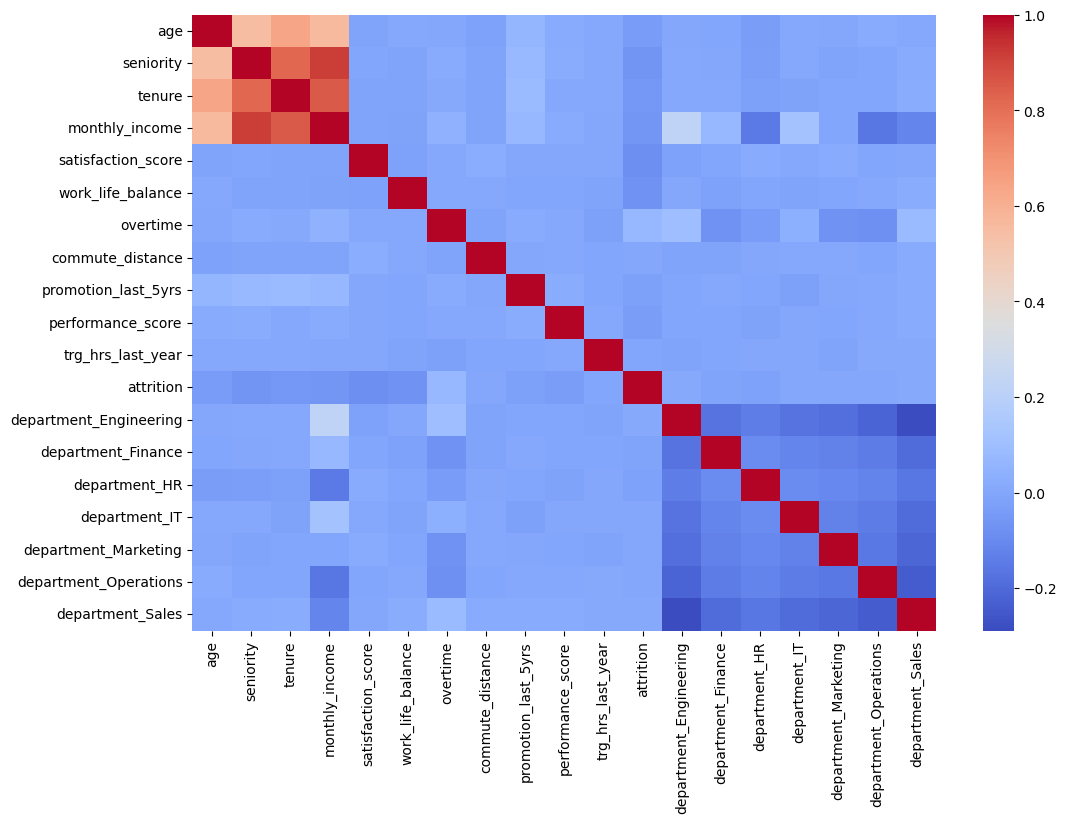

In [20]:
#The departments show proportional attrition to their counts. Does not show lot of correlation initially.
plt.figure(figsize=(12,8))
sns.heatmap(df_subset.corr(), cmap='coolwarm')

In [21]:
df_subset.to_csv(
    "encoded_attrition_data.csv",
    index=False
)